In [206]:
#import lib


In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(color_codes= True)

#import warnings
import warnings
warnings.filterwarnings('ignore')



%matplotlib inline

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 300)

In [208]:
#read file
application_data= pd.read_csv(r"C:\Users\prath\Downloads\application_data.csv")
previous_apllication= pd.read_csv(r"C:\Users\prath\Downloads\previous_application.csv")

In [209]:
application_data.shape


(307511, 122)

**DATA CLEANING**


In [211]:
#counting the percentage of null data
application_missing= application_data.count()/len(application_data)
application_missing= (1- application_missing)*100
application_missing.sort_values(ascending=False).head(60)

COMMONAREA_MEDI                 69.872297
COMMONAREA_AVG                  69.872297
COMMONAREA_MODE                 69.872297
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
NONLIVINGAPARTMENTS_MEDI        69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_MODE           68.354953
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAPARTMENTS_MEDI           68.354953
FLOORSMIN_AVG                   67.848630
FLOORSMIN_MODE                  67.848630
FLOORSMIN_MEDI                  67.848630
YEARS_BUILD_MEDI                66.497784
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_AVG                 66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_MEDI                   59.376738
LANDAREA_MODE                   59.376738
LANDAREA_AVG                    59.376738
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
BASEMENTAREA_MODE               58.515956
EXT_SOURCE_1                    56

In [212]:
#removing the columns which has more than 50 percentage of null values
application_nonmissing= application_data.loc[:, application_missing<50]
application_nonmissing.shape


(307511, 81)

In [214]:
application_nonmissing['DAYS_BIRTH'].head()


0    -9461
1   -16765
2   -19046
3   -19005
4   -19932
Name: DAYS_BIRTH, dtype: int64

In [215]:
#change clients age in days to years
application_nonmissing['DAYS_BIRTH']= -round(application_nonmissing['DAYS_BIRTH']/365,0)
application_nonmissing['DAYS_BIRTH'].head()


0    26.0
1    46.0
2    52.0
3    52.0
4    55.0
Name: DAYS_BIRTH, dtype: float64

In [216]:
#covert  days employed to years
application_nonmissing['DAYS_EMPLOYED']= -round(application_nonmissing['DAYS_EMPLOYED']/365,0)
application_nonmissing['DAYS_EMPLOYED'].head()


0    2.0
1    3.0
2    1.0
3    8.0
4    8.0
Name: DAYS_EMPLOYED, dtype: float64

In [217]:
#change days registration to years
application_nonmissing['DAYS_REGISTRATION']= -round(application_nonmissing['DAYS_REGISTRATION']/365,0)
application_nonmissing['DAYS_REGISTRATION'].head()


0    10.0
1     3.0
2    12.0
3    27.0
4    12.0
Name: DAYS_REGISTRATION, dtype: float64

In [218]:
#change days id publish  to years
application_nonmissing['DAYS_ID_PUBLISH']= -round(application_nonmissing['DAYS_ID_PUBLISH']/365,0)
application_nonmissing['DAYS_ID_PUBLISH'].head()


0    6.0
1    1.0
2    7.0
3    7.0
4    9.0
Name: DAYS_ID_PUBLISH, dtype: float64

In [219]:
#checking the null values
application_nonmissing.isnull().sum()

SK_ID_CURR                           0
TARGET                               0
NAME_CONTRACT_TYPE                   0
CODE_GENDER                          0
FLAG_OWN_CAR                         0
FLAG_OWN_REALTY                      0
CNT_CHILDREN                         0
AMT_INCOME_TOTAL                     0
AMT_CREDIT                           0
AMT_ANNUITY                         12
AMT_GOODS_PRICE                    278
NAME_TYPE_SUITE                   1292
NAME_INCOME_TYPE                     0
NAME_EDUCATION_TYPE                  0
NAME_FAMILY_STATUS                   0
NAME_HOUSING_TYPE                    0
REGION_POPULATION_RELATIVE           0
DAYS_BIRTH                           0
DAYS_EMPLOYED                        0
DAYS_REGISTRATION                    0
DAYS_ID_PUBLISH                      0
FLAG_MOBIL                           0
FLAG_EMP_PHONE                       0
FLAG_WORK_PHONE                      0
FLAG_CONT_MOBILE                     0
FLAG_PHONE               

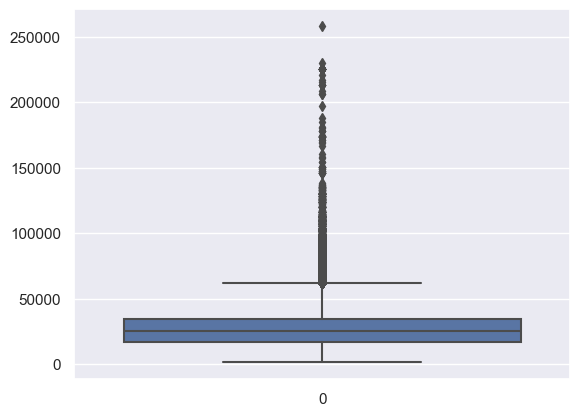

In [220]:
#'AMT_ANNUITY' column has very less null values. trying to impute missing values
sns.boxplot(application_nonmissing.AMT_ANNUITY)
plt.show()

In [221]:
#this column has very higher values so i am using median dor the missing values in this column
application_nonmissing['AMT_ANNUITY']= application_nonmissing['AMT_ANNUITY'].fillna(application_nonmissing['AMT_ANNUITY'].median())

In [222]:
application_nonmissing.shape

(307511, 81)

In [223]:
application_nonmissing['OCCUPATION_TYPE'].value_counts(dropna= False)

OCCUPATION_TYPE
NaN                      96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17]),
 [Text(0, 0, 'Laborers'),
  Text(1, 0, 'Core staff'),
  Text(2, 0, 'Accountants'),
  Text(3, 0, 'Managers'),
  Text(4, 0, 'Drivers'),
  Text(5, 0, 'Sales staff'),
  Text(6, 0, 'Cleaning staff'),
  Text(7, 0, 'Cooking staff'),
  Text(8, 0, 'Private service staff'),
  Text(9, 0, 'Medicine staff'),
  Text(10, 0, 'Security staff'),
  Text(11, 0, 'High skill tech staff'),
  Text(12, 0, 'Waiters/barmen staff'),
  Text(13, 0, 'Low-skill Laborers'),
  Text(14, 0, 'Realty agents'),
  Text(15, 0, 'Secretaries'),
  Text(16, 0, 'IT staff'),
  Text(17, 0, 'HR staff')])

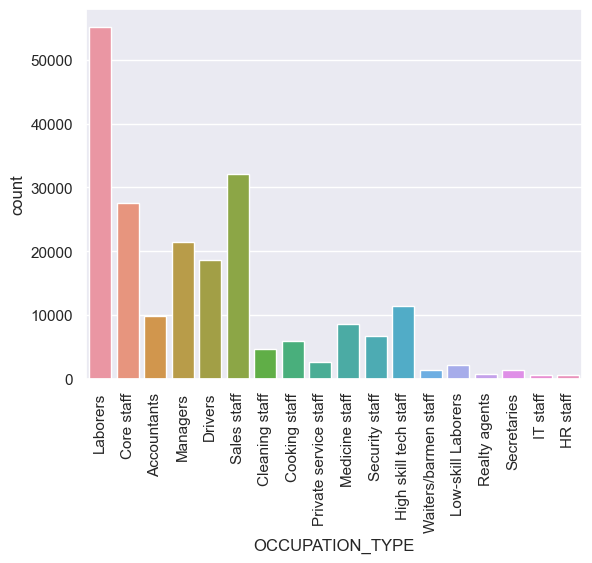

In [224]:
#seeing  the OCCUPATION_TYPE distribution
sns.countplot(x='OCCUPATION_TYPE', data= application_nonmissing)
plt.xticks(rotation= 90)

In [225]:
#as this is a categorical column , we can only replace it by mode value
#but replacing the all null values with laborers is a not good idea so we will leave it as it is and we will not do any missing values treatment.

In [226]:
#calculationg the missing values perecentage 
application_nonmissing.isnull().sum()/len(application_nonmissing)*100

SK_ID_CURR                       0.000000
TARGET                           0.000000
NAME_CONTRACT_TYPE               0.000000
CODE_GENDER                      0.000000
FLAG_OWN_CAR                     0.000000
FLAG_OWN_REALTY                  0.000000
CNT_CHILDREN                     0.000000
AMT_INCOME_TOTAL                 0.000000
AMT_CREDIT                       0.000000
AMT_ANNUITY                      0.000000
AMT_GOODS_PRICE                  0.090403
NAME_TYPE_SUITE                  0.420148
NAME_INCOME_TYPE                 0.000000
NAME_EDUCATION_TYPE              0.000000
NAME_FAMILY_STATUS               0.000000
NAME_HOUSING_TYPE                0.000000
REGION_POPULATION_RELATIVE       0.000000
DAYS_BIRTH                       0.000000
DAYS_EMPLOYED                    0.000000
DAYS_REGISTRATION                0.000000
DAYS_ID_PUBLISH                  0.000000
FLAG_MOBIL                       0.000000
FLAG_EMP_PHONE                   0.000000
FLAG_WORK_PHONE                  0

In [227]:
application_nonmissing["EXT_SOURCE_3"].head(10)


0    0.139376
1         NaN
2    0.729567
3         NaN
4         NaN
5    0.621226
6    0.492060
7    0.540654
8    0.751724
9         NaN
Name: EXT_SOURCE_3, dtype: float64

<Axes: ylabel='Frequency'>

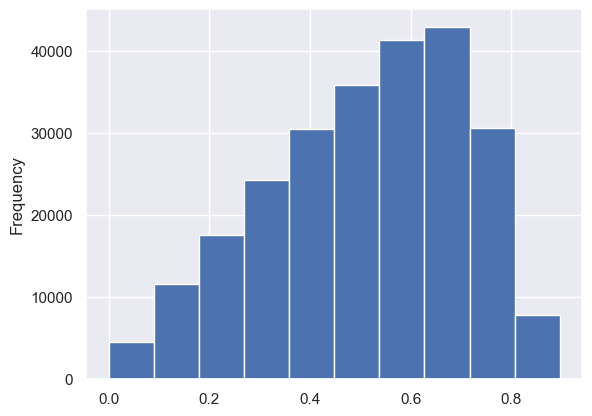

In [228]:
#plotting the distribution
application_nonmissing['EXT_SOURCE_3'].plot.hist()

In [229]:
application_nonmissing['EXT_SOURCE_3'].mean()



0.5108529061799658

In [230]:
application_nonmissing['EXT_SOURCE_3'].mode()

0    0.7463
Name: EXT_SOURCE_3, dtype: float64

In [231]:
#this data is skewed normal distribution so the median value is the better choice to fill null values
application_nonmissing['EXT_SOURCE_3']= application_nonmissing['EXT_SOURCE_3'].fillna(application_nonmissing['EXT_SOURCE_3'].median())


In [232]:
application_nonmissing['NAME_TYPE_SUITE'].value_counts(dropna= False)

NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               866
Group of people       271
Name: count, dtype: int64

In [233]:
#it is categorical data so we can fill null values with mode
application_nonmissing['NAME_TYPE_SUITE'].fillna(value=(application_nonmissing['NAME_TYPE_SUITE'].mode()[0]), inplace = True)

In [234]:
application_nonmissing['YEARS_BEGINEXPLUATATION_AVG'].value_counts(dropna= False)

YEARS_BEGINEXPLUATATION_AVG
NaN       150007
0.9871      4311
0.9856      4189
0.9861      4171
0.9801      4123
0.9866      4114
0.9806      4096
0.9851      4096
0.9811      3986
0.9816      3982
0.9831      3970
0.9876      3942
0.9796      3933
0.9841      3881
0.9821      3872
0.9846      3856
0.9791      3846
0.9836      3803
0.9781      3728
0.9786      3666
0.9826      3648
0.9776      3460
0.9771      3441
0.9881      3425
0.9767      3180
0.9762      3003
0.9886      2897
0.9742      2876
0.9757      2783
0.9747      2754
0.9752      2739
0.9737      2708
0.9896      2477
0.9732      2464
0.9891      2442
0.9727      2277
0.9722      1954
0.9901      1932
0.9906      1540
0.9717      1493
0.9911      1199
0.9970      1110
0.9980      1096
0.9712      1078
0.9975      1074
0.9985      1062
0.9916       986
0.9990       906
0.9965       902
0.9921       882
0.9707       867
0.9960       853
0.9702       835
0.9925       784
0.9955       762
0.9930       754
0.9697       738
0.9

<Axes: ylabel='Frequency'>

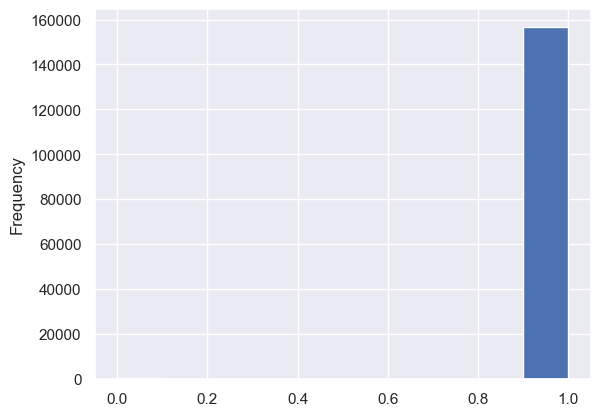

In [235]:
application_nonmissing['YEARS_BEGINEXPLUATATION_AVG'].plot.hist()

In [236]:
#As you can see, mostly the values are 1's. So, this column is mostly acting as a constant and has no variation. So, we can ignore this column for analysis.

In [237]:
application_nonmissing['FLOORSMAX_AVG'].head()

0    0.0833
1    0.2917
2       NaN
3       NaN
4       NaN
Name: FLOORSMAX_AVG, dtype: float64

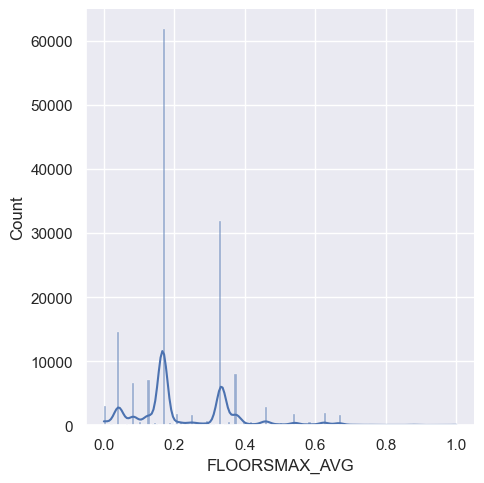

In [238]:
sns.displot( data= application_nonmissing, x= 'FLOORSMAX_AVG', kde= True)

In [239]:
#FLOORSMAX_AVG shows a normal distribution so we can replace the null values by mean
application_nonmissing['FLOORSMAX_AVG'].fillna(value=(application_nonmissing['FLOORSMAX_AVG'].mean()), inplace = True)

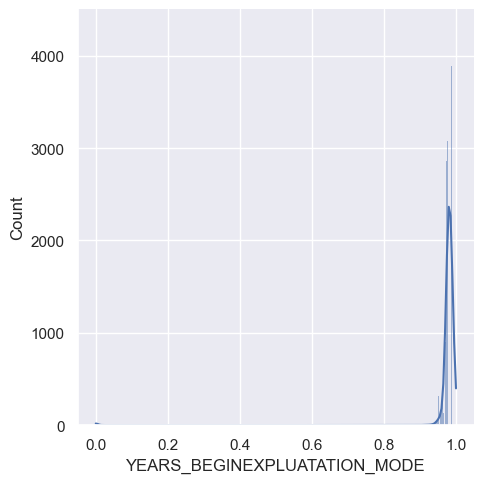

In [240]:
sns.displot( data= application_nonmissing, x= 'YEARS_BEGINEXPLUATATION_MODE', kde= True)

In [241]:
#As you can see, mostly the values are 1's. So, this column is mostly acting as a constant and has no variation. So, we can ignore this column for analysis.

In [242]:
application_nonmissing['FLOORSMAX_MODE'].head()

0    0.0833
1    0.2917
2       NaN
3       NaN
4       NaN
Name: FLOORSMAX_MODE, dtype: float64

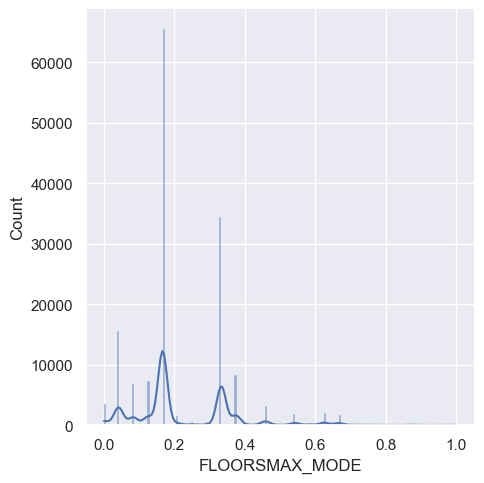

In [243]:
sns.displot( data= application_nonmissing, x= 'FLOORSMAX_MODE', kde= True)

In [244]:
#FLOORSMAX_MODE shows a normal distribution so we can replace it by mean value
application_nonmissing['FLOORSMAX_MODE'].fillna(value=(application_nonmissing['FLOORSMAX_MODE'].mean()), inplace = True)

In [245]:
application_nonmissing['YEARS_BEGINEXPLUATATION_MEDI'].value_counts(dropna= False)

YEARS_BEGINEXPLUATATION_MEDI
NaN       150007
0.9871      4314
0.9861      4247
0.9856      4199
0.9866      4138
0.9801      4115
0.9806      4069
0.9851      4032
0.9796      3963
0.9876      3948
0.9816      3930
0.9831      3919
0.9811      3899
0.9791      3889
0.9841      3860
0.9821      3837
0.9846      3830
0.9781      3753
0.9836      3709
0.9826      3697
0.9786      3679
0.9776      3478
0.9771      3464
0.9881      3416
0.9767      3189
0.9762      3044
0.9742      2920
0.9886      2823
0.9757      2814
0.9747      2774
0.9737      2751
0.9752      2724
0.9732      2486
0.9891      2460
0.9896      2453
0.9727      2270
0.9722      1971
0.9901      1912
0.9717      1508
0.9906      1497
0.9911      1170
0.9970      1152
0.9975      1123
0.9980      1114
0.9985      1073
0.9712      1069
0.9965       960
0.9916       959
0.9990       926
0.9960       899
0.9707       864
0.9921       861
0.9702       834
0.9925       768
0.9955       760
0.9697       748
0.9930       734
0.

In [246]:
#As you can see, mostly the values are 1's. So, this column is mostly acting as a constant and has no variation. So, we can ignore this column for analysis.

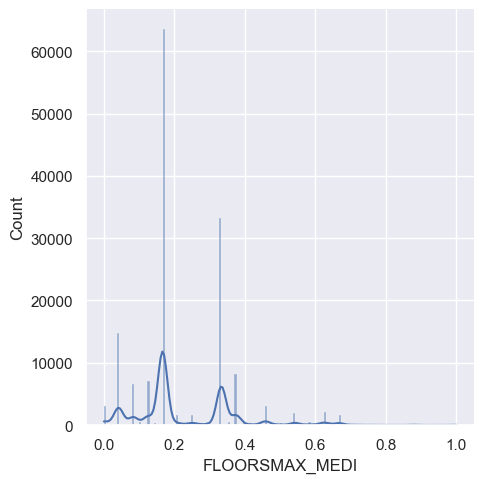

In [247]:
sns.displot( data= application_nonmissing, x= 'FLOORSMAX_MEDI', kde= True)

In [248]:
#FLOORSMAX_MEDI shows a normal distribution so we can replace it by mean value
application_nonmissing['FLOORSMAX_MEDI'].fillna(value=(application_nonmissing['FLOORSMAX_MEDI'].mean()), inplace = True)

In [249]:
application_nonmissing['AMT_REQ_CREDIT_BUREAU_WEEK'].head(10)

0    0.0
1    0.0
2    0.0
3    NaN
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    NaN
Name: AMT_REQ_CREDIT_BUREAU_WEEK, dtype: float64

<Axes: ylabel='Frequency'>

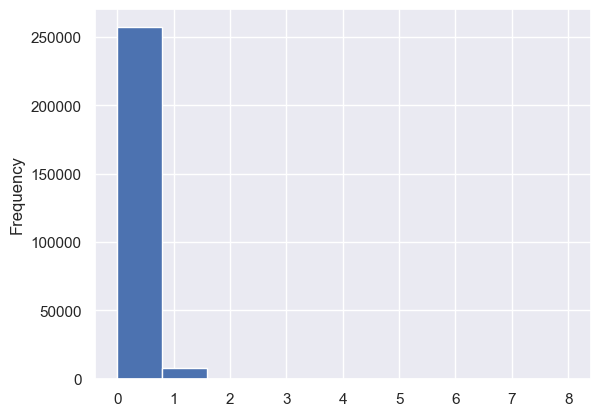

In [250]:
#counting the unique values
num_unique_values =  len(application_nonmissing.AMT_REQ_CREDIT_BUREAU_WEEK.unique())
application_nonmissing['AMT_REQ_CREDIT_BUREAU_WEEK'].plot.hist(bins = num_unique_values)

In [251]:
#As you can see, mostly the values are 0's. So, this column is mostly acting as a constant and has no variation.So, we can ignore this column for analysis.

In [252]:
application_nonmissing['DEF_60_CNT_SOCIAL_CIRCLE'].unique()

array([ 2.,  0.,  1., nan,  3.,  5.,  4.,  7., 24.,  6.])

In [253]:
application_nonmissing['DEF_60_CNT_SOCIAL_CIRCLE'].mean()

0.10004894123788705

In [254]:
application_nonmissing['DEF_60_CNT_SOCIAL_CIRCLE'].median()

0.0

In [255]:
application_nonmissing['DEF_60_CNT_SOCIAL_CIRCLE'].mode()

0    0.0
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: float64

<Axes: ylabel='Frequency'>

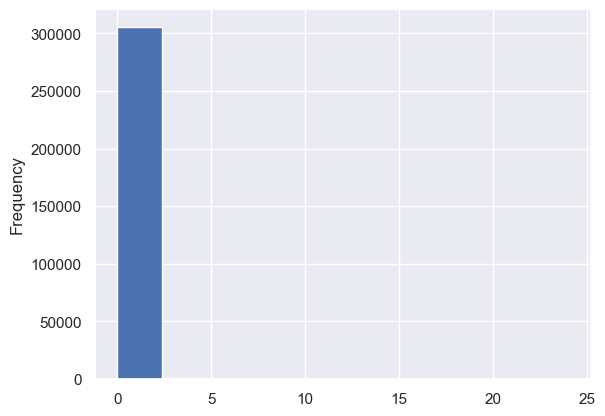

In [256]:
application_nonmissing['DEF_60_CNT_SOCIAL_CIRCLE'].plot.hist()

In [257]:
#so most of the values are 0. we can replace the missing values by mode
application_nonmissing['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(value=(application_nonmissing['DEF_60_CNT_SOCIAL_CIRCLE'].mode()), inplace = True)


In [258]:
application_nonmissing['AMT_REQ_CREDIT_BUREAU_QRT']=application_nonmissing['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(
                application_nonmissing['DEF_60_CNT_SOCIAL_CIRCLE'].mode().iloc[0])

In [259]:
application_nonmissing['AMT_REQ_CREDIT_BUREAU_QRT'].isna().sum()

0

In [260]:
application_nonmissing[application_nonmissing.describe().columns].isna().sum().tolist()

[0,
 0,
 0,
 0,
 0,
 0,
 278,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 660,
 0,
 150007,
 0,
 150007,
 0,
 150007,
 0,
 148431,
 1021,
 1021,
 1021,
 1021,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 41519,
 41519,
 41519,
 41519,
 0,
 41519]

In [261]:
nulls = application_nonmissing.isnull().sum()
nulls[nulls > 0]

AMT_GOODS_PRICE                    278
OCCUPATION_TYPE                  96391
CNT_FAM_MEMBERS                      2
EXT_SOURCE_2                       660
YEARS_BEGINEXPLUATATION_AVG     150007
YEARS_BEGINEXPLUATATION_MODE    150007
YEARS_BEGINEXPLUATATION_MEDI    150007
TOTALAREA_MODE                  148431
EMERGENCYSTATE_MODE             145755
OBS_30_CNT_SOCIAL_CIRCLE          1021
DEF_30_CNT_SOCIAL_CIRCLE          1021
OBS_60_CNT_SOCIAL_CIRCLE          1021
DEF_60_CNT_SOCIAL_CIRCLE          1021
DAYS_LAST_PHONE_CHANGE               1
AMT_REQ_CREDIT_BUREAU_HOUR       41519
AMT_REQ_CREDIT_BUREAU_DAY        41519
AMT_REQ_CREDIT_BUREAU_WEEK       41519
AMT_REQ_CREDIT_BUREAU_MON        41519
AMT_REQ_CREDIT_BUREAU_YEAR       41519
dtype: int64

*data is clean*

**Target**

In [264]:
application_nonmissing['TARGET'].head()

0    1
1    0
2    0
3    0
4    0
Name: TARGET, dtype: int64

In [265]:
application_nonmissing['TARGET'].unique()

array([1, 0], dtype=int64)

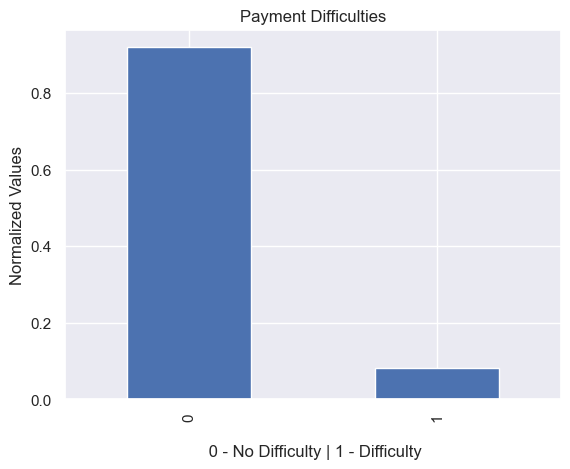

In [266]:
#plotting the target
application_nonmissing.TARGET.value_counts(normalize  = True).plot.bar()
plt.title("Payment Difficulties")
plt.xlabel("\n 0 - No Difficulty | 1 - Difficulty")
plt.ylabel("Normalized Values")
plt.show()

In [267]:
#finding the imbalance
application_nonmissing[application_nonmissing.TARGET == 0].shape[0] / application_nonmissing[application_nonmissing.TARGET == 1].shape[0]

11.387150050352467

In [268]:
application_nonmissing.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'YEARS_BEGINEXPLUATATION_AVG', 'FLOOR

In [269]:
#casting all variables into numeric in the datset
numeric_col=['TARGET', 'CNT_CHILDREN','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','REGION_POPULATION_RELATIVE','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH',
             'HOUR_APPR_PROCESS_START','LIVE_REGION_NOT_WORK_REGION','REG_CITY_NOT_LIVE_CITY','REG_CITY_NOT_WORK_CITY','LIVE_CITY_NOT_WORK_CITY']
application_nonmissing[numeric_col]=application_nonmissing[numeric_col].apply(pd.to_numeric)

In [270]:
#creating bins for income amount
bins=[0,25000,50000,75000,100000,125000,150000,175000,200000,225000,250000,275000,300000,325000,350000,400000,425000,450000,475000,500000,10000000]
slot=['0-250000','250000-50000','50000-75000','75000-100000','100000-125000','125000-150000','150000-175000','175000-200000','200000-225000','225000-250000',
      '250000-275000','275000-300000','300000-325000','325000-350000','350000-375000','375000-400000','400000-425000','425000-450000','450000-475000','475000-500000',
      ]
application_nonmissing['AMT_INCOME_RANGE']= pd.cut(application_nonmissing['AMT_INCOME_TOTAL'],bins,labels=slot)

In [271]:
#creating bins for credit amount
bins=[0,150000,200000,250000,300000,350000,400000,450000,500000,550000,600000,650000,700000,750000,800000,850000,900000,100000000]
slots=['0-150000','150000-200000','2000000-250000','250000-3000000','300000-350000','350000-400000','400000-450000','450000-500000','500000-550000','550000-600000',
       '600000-650000','650000-700000','700000-750000','750000-800000','800000-850000','850000-900000','900000 and above']
application_nonmissing['AMT_CREDIT_RANGE']= pd.cut(application_nonmissing['AMT_CREDIT'],bins=bins, labels=slots)

now, we will analyse numerical and categorical data

In [273]:
#divdiding the datset into two dataset of target 1= (client with payment difficulty) and target=0 (all other)
target0 = application_nonmissing.loc[application_nonmissing['TARGET'] == 0]
target1 = application_nonmissing.loc[application_nonmissing['TARGET'] == 1]

In [274]:
num_col = application_nonmissing.describe().columns
num_col

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'YEARS_BEGINEXPLUATATION_AVG', 'FLOORSMAX_AVG',
       'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE',
       'YEARS_BEGINEXPLUATATION_MEDI', 'FLOORSMAX_MEDI', 'TOTALAREA_MODE',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
      

In [275]:
#categorical columns are:
cat_col = list(set(application_nonmissing.columns) - set(application_nonmissing.describe().columns)) 
cat_col

['FLAG_OWN_CAR',
 'AMT_CREDIT_RANGE',
 'OCCUPATION_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_INCOME_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_CONTRACT_TYPE',
 'NAME_FAMILY_STATUS',
 'CODE_GENDER',
 'NAME_HOUSING_TYPE',
 'EMERGENCYSTATE_MODE',
 'AMT_INCOME_RANGE',
 'ORGANIZATION_TYPE']

**univariate analysis**

In [277]:
def mplot(df, col, title, hue= None):
    plt.rcParams['axes.titlesize']= 20
    temp = pd.Series(data = hue)
    
    
    plt.xticks(rotation=90)
    plt.yscale('log')
    plt.title(title)
    ax= sns.countplot(data=df, x= col, order=df[col].value_counts().index, hue= hue)
    plt.show()
    
    

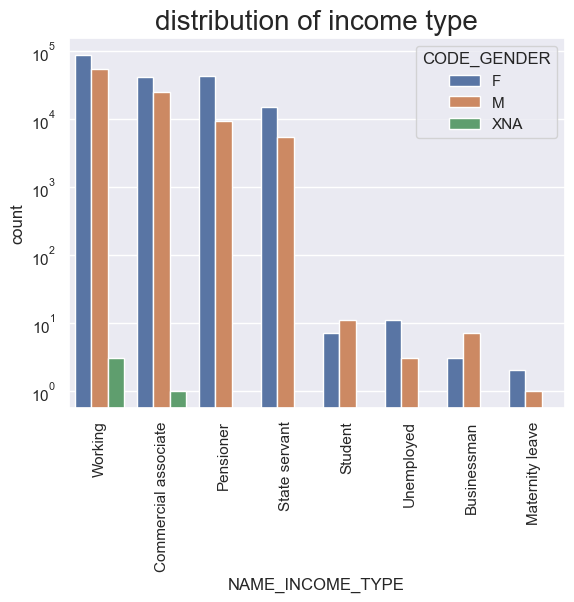

In [278]:
#plot income type
mplot(target0, col= 'NAME_INCOME_TYPE', title= 'distribution of income type', hue= 'CODE_GENDER')

*as you can see females are having more credits than male

*for working, commercial association, pensioner , state servent the number of  credits are higher than other

*for students , unemployed, businessman, maternity leave the number of credits are less

as you can see, cash loans are having higher number of credits than revolving loans contract type

female numbers is higher here also than male

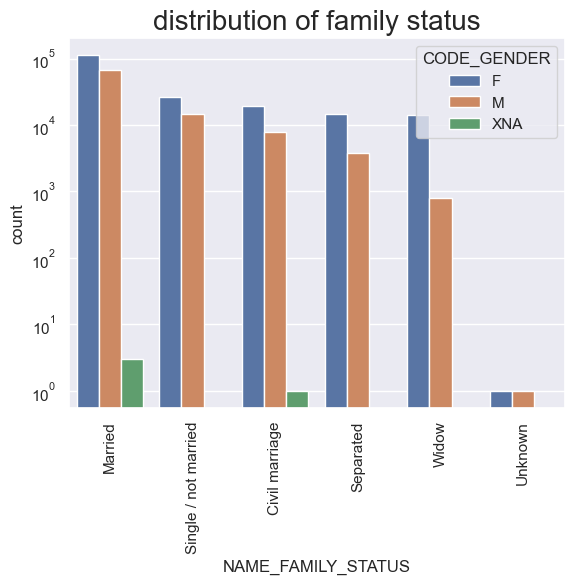

In [284]:
mplot(target0, col= 'NAME_FAMILY_STATUS', title= 'distribution of family status', hue= 'CODE_GENDER')


married are having higher credit

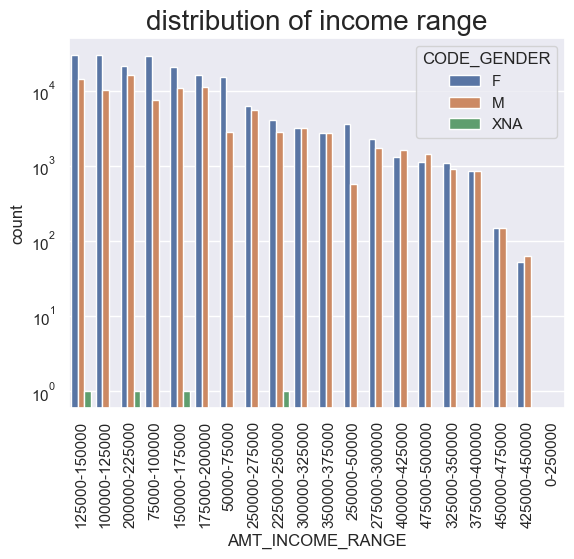

In [286]:
mplot(target0, col= 'AMT_INCOME_RANGE', title= 'distribution of income range', hue= 'CODE_GENDER')

female counts are higher than male

income  range from 100000 to 200000 is having more number of credits

females are having more credits than male

In [290]:
target0

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_INCOME_RANGE,AMT_CREDIT_RANGE
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,46.0,3.0,3.0,1.0,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.622246,0.535276,0.9851,0.291700,0.9851,0.291700,0.9851,0.291700,0.0714,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,250000-275000,900000 and above
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,52.0,1.0,12.0,7.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.555912,0.729567,NaN,0.226282,NaN,0.222315,NaN,0.225897,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,50000-75000,0-150000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,52.0,8.0,27.0,7.0,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.650442,0.535276,NaN,0.226282,NaN,0.222315,NaN,0.225897,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0.0,NaN,125000-150000,300000-350000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,55.0,8.0,12.0,9.0,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,Religion,0.322738,0.535276,NaN,0.226282,NaN,0.222315,NaN,0.225897,NaN,NaN,0.0,0.0,0.0,0.0,-1106.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,100000-125000,500000-550000
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,454500.0,"Spouse, partner",State servant,Secondary / secondary special,Married,House / apartment,0.035792,46.0,4.0,14.0,1.0,1,1,1,1,1,0,Laborers,2.0,2,2,WEDNESDAY,16,0,0,0,0,0,0,Other,0.354225,0.621226,NaN,0.226282,NaN,0.222315,NaN,0.225897,NaN,NaN,0.0,0.0,0.0,0.0,-2536.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,75000-100000,450000-500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307505

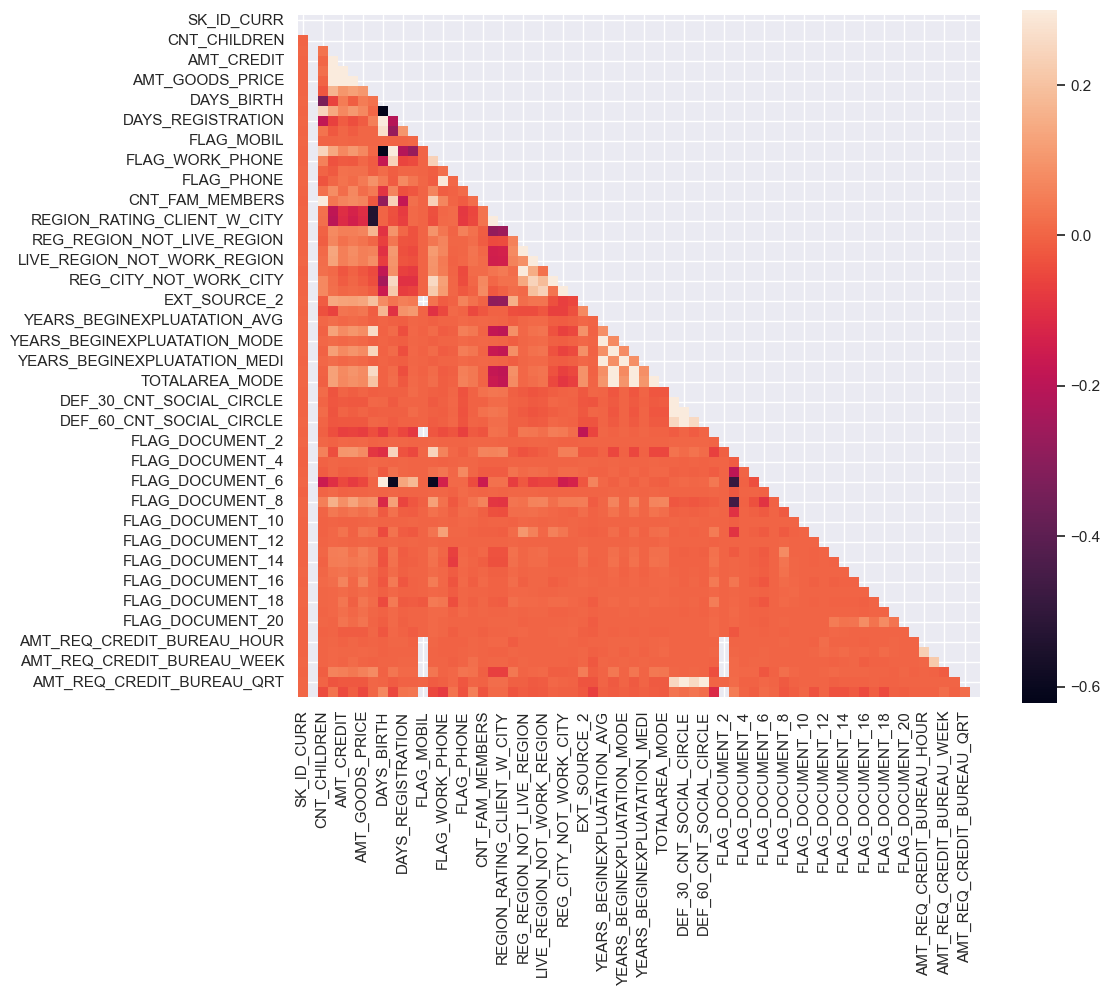

In [291]:
import numpy as np
corr = target0.corr(numeric_only=True)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(11, 9))
with sns.axes_style("white"):
    ax = sns.heatmap(corr, mask=mask, vmax=.3, square=True)

as you can see from above correlation heatmap:
1]income amount is inversly proportional to the number of children the client haveand vice-versa
2]credit amount is inversly proportional to the date of birth, which means credit amount is higher for low age and vice-versa.
3]credit amount is higher to densly populated area


**finding the top 10 correlation**

In [294]:
 target0.corr(numeric_only=True)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,1.000000,NaN,-0.000716,0.001739,-0.000342,0.000071,-0.000205,0.000360,0.001324,-0.001744,0.001535,0.000123,0.002925,-0.001717,-0.000854,0.003319,0.001408,0.000229,-0.002790,-0.000519,-0.000739,-0.000115,0.000104,0.000836,0.002784,-0.002885,-0.001696,0.000428,0.001589,0.000244,0.001202,0.002925,0.001442,0.002676,0.000952,0.002721,0.002040,-0.000695,0.000556,-0.000741,0.002382,-0.000998,0.001342,-0.003217,-0.004321,-0.001426,0.001972,-0.003047,0.001618,0.002007,-0.000852,-0.001900,-0.001092,0.001006,-0.001236,0.002330,-0.000753,0.001776,0.001194,0.000676,0.000832,-0.000485,-0.001879,-0.001725,0.002524,0.000054,0.002375,0.004349
TARGET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,-0.000716,NaN,1.000000,0.027397,0.003081,0.020909,-0.000525,-0.024363,-0.336847,0.243356,-0.185586,0.028569,0.001080,0.244274,0.055453,-0.001201,-0.029929,0.023460,0.878571,0.022842,0.021866,-0.005244,-0.012342,0.010857,0.017326,0.021587,0.072193,0.070988,-0.015455,-0.038306,0.007298,-0.005905,0.006545,-0.005826,0.006783,-0.005739,-0.006972,0.014471,-0.002246,0.014137,-0.002172,-0.008501,0.003736,0.055718,-0.003833,-0.016239,-0.158963,-0.001442,0.053919,-0.002358,-0.002859,-0.005059,0.000322,0.004340,-0.005455,0.003710,0.011775,0.001160,0.004181,0.001078,0.001302,-0.002983,-0.000432,0.000648,-0.001632,-0.010455,-0.002125,-0.042547
AMT_INCOME_TOTAL,0.001739,NaN,0.027397,1.000000,0.342799,0.418948,0.349462,0.167851,-0.062597,0.141254,-0.064963,-0.022840,0.000733,0.140744,-0.032404,-0.018814,0.002683,0.083705,0.034256,-0.186573,-0.200466,0.076743,0.068510,0.137174,0.127701,0.010567,0.017618,0.020684,0.139598,-0.062497,0.016485,0.127418,0.015393,0.122202,0.016431,0.126417,0.125714,-0.027828,-0.027621,-0.027690,-0.027593,-0.041338,-0.002857,-0.039251,0.001160,0.004161,-0.100271,0.009035,0.159350,0.040088,0.000637,0.005402,0.005680,0.049421,0.045590,0.023814,0.015800,0.005141,0.008214,0.005762,0.000840,-0.000869,0.001417,0.007862,0.006234,0.061470,-0.027897,0.029536
AMT_CREDIT,-0.000342,NaN,0.003081,0.342799,1.000000,0.771297,0.987250,0.100604,0.047426,0.072517,-0.013409,0.001405,0.001498,0.071257,-0.017119,0.023096,0.026725,0.017074,0.064536,-0.103337,-0.112238,0.053619,0.024617,0.053735,0.054250,-0.025036,-0.015703,0.002506,0.129140,0.031087,0.005943,0.076913,0.004842,0.074754,0.005480,0.076504,0.072281,-0.000914,-0.019851,-0.000892,-0.022225,-0.069540,0.005490,0.100334,0.000567,-0.011750,-0.050260,-0.003613,0.084524,0.022297,-0.003243,0.028341,0.003956,0.

In [295]:
 target0.corr(numeric_only=True).abs().unstack()

SK_ID_CURR                  SK_ID_CURR                    1.000000
                            TARGET                             NaN
                            CNT_CHILDREN                  0.000716
                            AMT_INCOME_TOTAL              0.001739
                            AMT_CREDIT                    0.000342
                                                            ...   
AMT_REQ_CREDIT_BUREAU_YEAR  AMT_REQ_CREDIT_BUREAU_DAY     0.003798
                            AMT_REQ_CREDIT_BUREAU_WEEK    0.019085
                            AMT_REQ_CREDIT_BUREAU_MON     0.004889
                            AMT_REQ_CREDIT_BUREAU_QRT     0.018215
                            AMT_REQ_CREDIT_BUREAU_YEAR    1.000000
Length: 4624, dtype: float64

In [296]:
#drop na values
import pandas as pd

correlation_0 = target0.corr(numeric_only=True).abs().unstack().sort_index().dropna()
correlation_0

AMT_ANNUITY                   AMT_ANNUITY                     1.000000
                              AMT_CREDIT                      0.771297
                              AMT_GOODS_PRICE                 0.776674
                              AMT_INCOME_TOTAL                0.418948
                              AMT_REQ_CREDIT_BUREAU_DAY       0.002392
                                                                ...   
YEARS_BEGINEXPLUATATION_MODE  SK_ID_CURR                      0.001442
                              TOTALAREA_MODE                  0.097297
                              YEARS_BEGINEXPLUATATION_AVG     0.971032
                              YEARS_BEGINEXPLUATATION_MEDI    0.962064
                              YEARS_BEGINEXPLUATATION_MODE    1.000000
Length: 4465, dtype: float64

In [297]:
#get the values which are not equal to 1.0
correlation_0 = correlation_0[ correlation_0 != 1.0 ]

print(correlation_0)

AMT_ANNUITY                   AMT_CREDIT                      0.771297
                              AMT_GOODS_PRICE                 0.776674
                              AMT_INCOME_TOTAL                0.418948
                              AMT_REQ_CREDIT_BUREAU_DAY       0.002392
                              AMT_REQ_CREDIT_BUREAU_HOUR      0.003149
                                                                ...   
YEARS_BEGINEXPLUATATION_MODE  REG_REGION_NOT_WORK_REGION      0.011152
                              SK_ID_CURR                      0.001442
                              TOTALAREA_MODE                  0.097297
                              YEARS_BEGINEXPLUATATION_AVG     0.971032
                              YEARS_BEGINEXPLUATATION_MEDI    0.962064
Length: 4396, dtype: float64


**Default correlation**

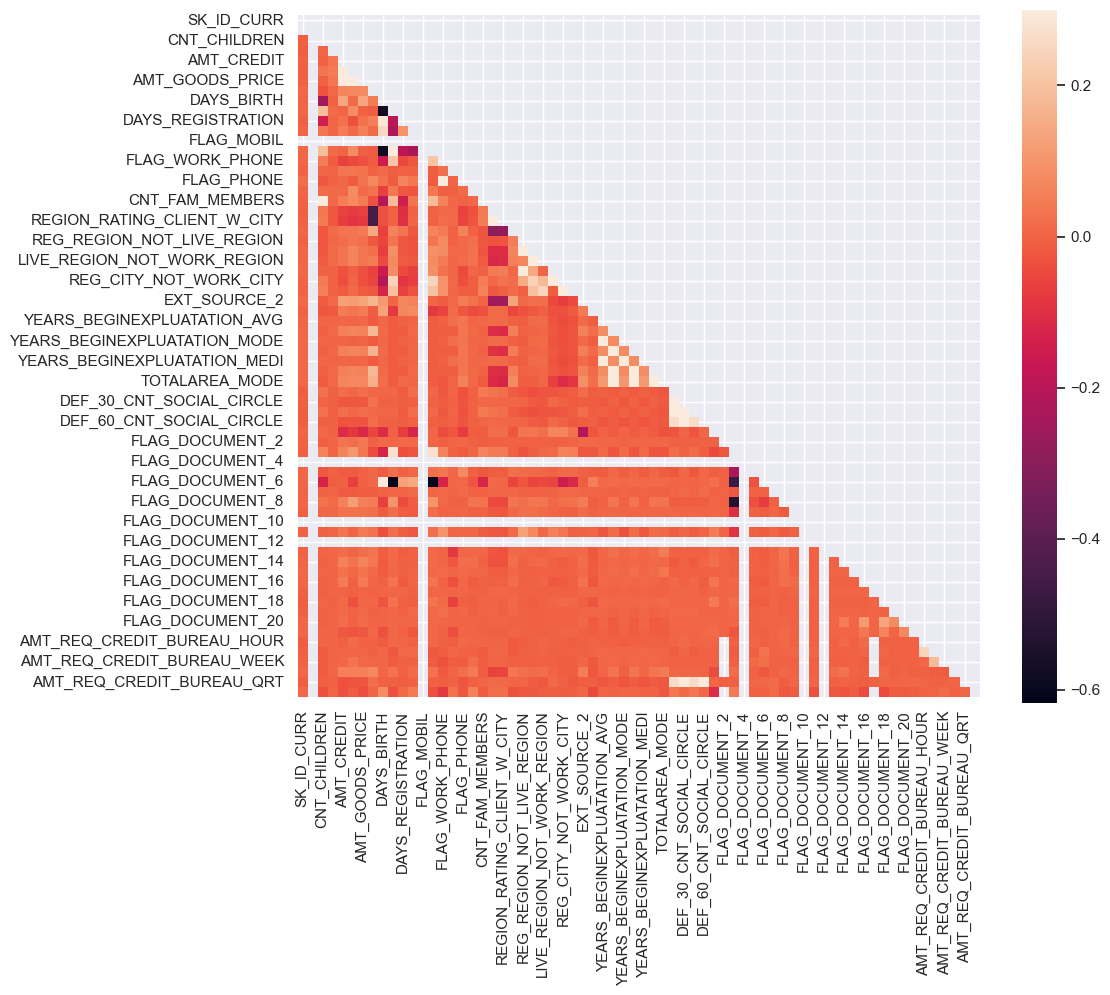

In [300]:
corr = target1.corr(numeric_only=True)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(11, 9))
with sns.axes_style("white"):
    ax = sns.heatmap(corr, mask=mask, vmax=.3, square=True)

 this target 1 heatmap is quite a same oberservation just like target0.
 1]the clients permenent address does not match contact address are having less children and vice versa

In [302]:
correlation_1 = target1.corr(numeric_only=True).abs()
correlation_1 = correlation_1.unstack().sort_values(kind="quicksort")
correlation_1 = correlation_1.dropna()
correlation_1 = correlation_1[correlation_1 != 1.0]

print(correlation_1)

FLAG_DOCUMENT_20             REGION_RATING_CLIENT           0.000010
REGION_RATING_CLIENT         FLAG_DOCUMENT_20               0.000010
REG_CITY_NOT_LIVE_CITY       LIVE_REGION_NOT_WORK_REGION    0.000011
LIVE_REGION_NOT_WORK_REGION  REG_CITY_NOT_LIVE_CITY         0.000011
AMT_REQ_CREDIT_BUREAU_WEEK   AMT_INCOME_TOTAL               0.000018
                                                              ...   
FLOORSMAX_MEDI               FLOORSMAX_AVG                  0.997233
OBS_60_CNT_SOCIAL_CIRCLE     OBS_30_CNT_SOCIAL_CIRCLE       0.998269
OBS_30_CNT_SOCIAL_CIRCLE     OBS_60_CNT_SOCIAL_CIRCLE       0.998269
FLAG_EMP_PHONE               DAYS_EMPLOYED                  0.999702
DAYS_EMPLOYED                FLAG_EMP_PHONE                 0.999702
Length: 3884, dtype: float64


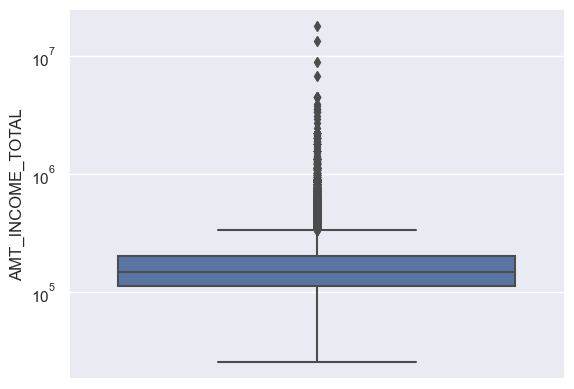

In [396]:
#distribution of income amount
sns.boxplot(data=target0, y='AMT_INCOME_TOTAL')
plt.yscale('log')
plt.show()


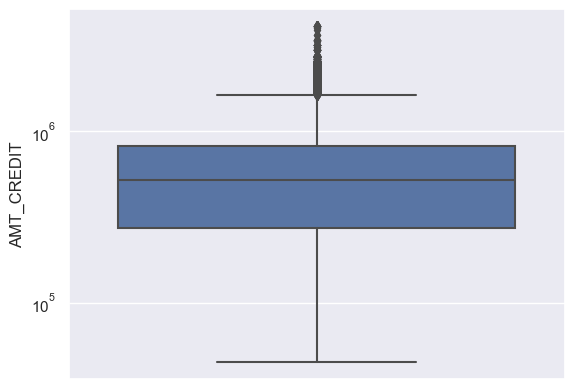

In [398]:
#distribution of credit amount
sns.boxplot(data=target0, y='AMT_CREDIT')
plt.yscale('log')
plt.show()


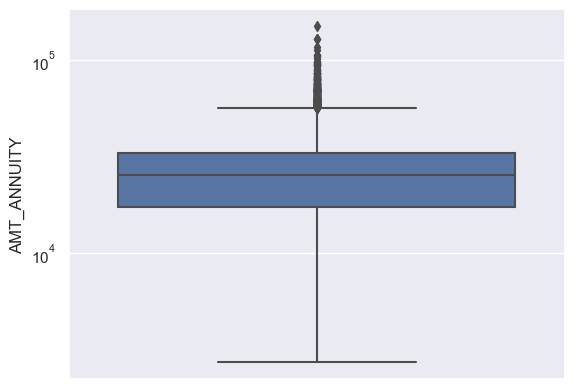

In [402]:
#distribution of annuity amount
sns.boxplot(data=target1, y='AMT_ANNUITY')
plt.yscale('log')
plt.show()


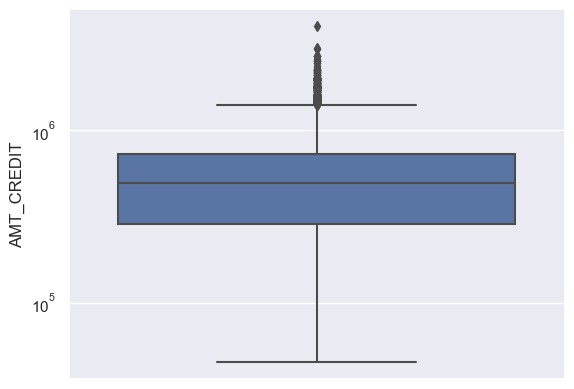

In [404]:
#distribution of credit amount
sns.boxplot(data=target1, y='AMT_CREDIT')
plt.yscale('log')
plt.show()


**reading previous application**

In [407]:
previous_application= pd.read_csv(r"C:\Users\prath\Downloads\previous_application.csv")
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [409]:
previous_application.shape

(1670214, 37)

In [411]:
# Number of unique id in previous application
previous_application.SK_ID_PREV.value_counts()

SK_ID_PREV
2030495    1
1035848    1
1526498    1
2148893    1
2437429    1
          ..
2811649    1
1221292    1
2780117    1
2194001    1
2418762    1
Name: count, Length: 1670214, dtype: int64

In [413]:
# Number of unique id in previous application
previous_application.SK_ID_CURR.value_counts()

SK_ID_CURR
187868    77
265681    73
173680    72
242412    68
206783    67
          ..
135285     1
311960     1
427136     1
241434     1
191629     1
Name: count, Length: 338857, dtype: int64

**merging dataframe: train and previous application based on SK_ID_PREV**

In [419]:
previous_train = application_nonmissing.merge(previous_application, left_on='SK_ID_CURR', 
                                         right_on='SK_ID_CURR', how='inner')

In [438]:
previous_train.columns.values

array(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE_x', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'AMT_CREDIT_x', 'AMT_ANNUITY_x',
       'AMT_GOODS_PRICE_x', 'NAME_TYPE_SUITE_x', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START_x', 'HOUR_APPR_PROCESS_START_x',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'YEARS_BEGINEXPL

In [421]:
previous_train.shape

(1413701, 119)

In [432]:
previous_application.columns.values

array(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT',
       'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT',
       'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT',
       'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED',
       'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION',
       'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE',
       'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO',
       'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA',
       'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP',
       'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE',
       'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION',
       'NFLAG_INSURED_ON_APPROVAL'], dtype=object)

**The merged dataframe also has multiple values for SK_ID_CURR**

In [424]:
previous_application.SK_ID_CURR.value_counts().head()

SK_ID_CURR
187868    77
265681    73
173680    72
242412    68
206783    67
Name: count, dtype: int64

In [426]:
#Segregating the dataset on Target=0 and Target=1
ptrain_0 = previous_train.loc[previous_train['TARGET'] == 0]
ptrain_1 = previous_train.loc[previous_train['TARGET'] == 1]

**bivariate analysis**

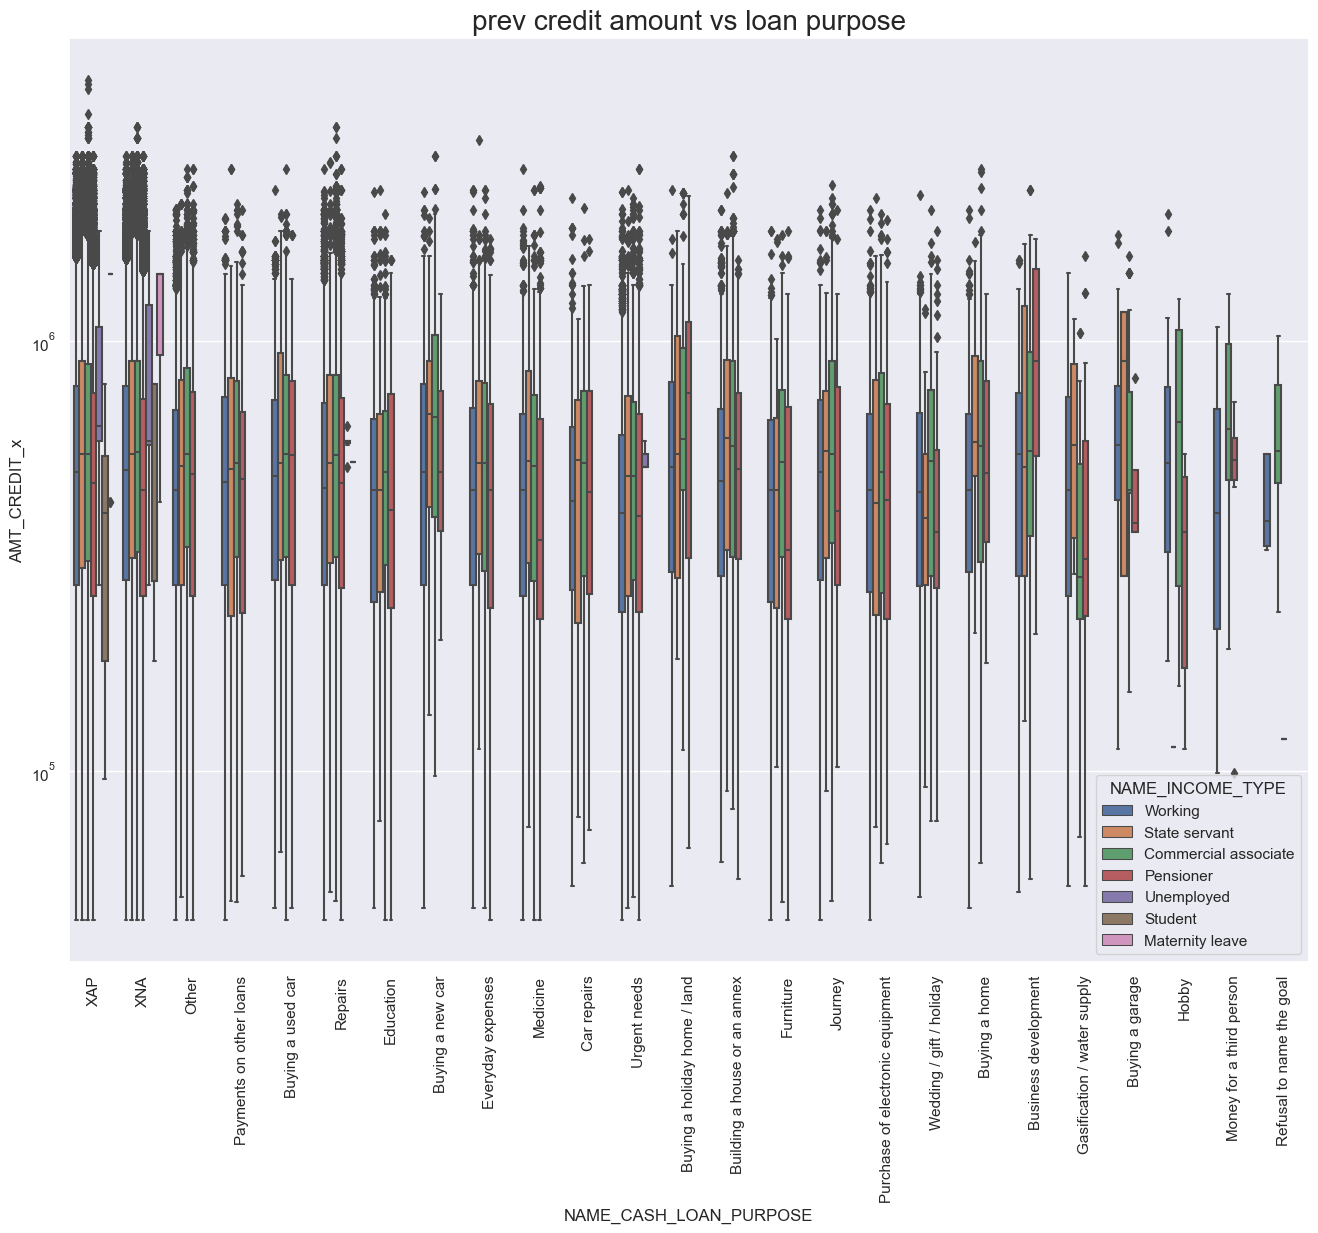

In [442]:
#box plotting for credit amount
plt.figure(figsize=(16,12))
plt.xticks(rotation=90)
plt.yscale('log')
sns.boxplot(data= previous_train, x='NAME_CASH_LOAN_PURPOSE', hue='NAME_INCOME_TYPE',y='AMT_CREDIT_x',orient ='v')
plt.title("prev credit amount vs loan purpose")
plt.show()